In [4]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Airbnb regression 
### Associated lectures: All material till lecture 13 

<div class="alert alert-info">

## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work in PrairieLearn.

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.

- The maximum group size is 2.
- Use group work as an opportunity to collaborate and learn new things from each other.
- Be respectful to each other and make sure you understand all the concepts in the assignment well.
- It is your responsibility to make sure your PrairieLearn group is set up correctly and that the assignment is submitted before the deadline.

### General submission instructions

- Please read the [Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2026S1/syllabus#use-of-generative-ai-in-the-course) before starting the homework assignment.
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
- **Save your work in JupyterLab:** Make sure `hw5.ipynb` is saved.
- **Choose one HW5 option:** HW5 has two dataset options in PrairieLearn. You are currently in the Airbnb regression option. Open and submit exactly one notebook, and do not submit both.
- **Check your saved submission in PrairieLearn:** Return to the PrairieLearn question page and click **Save only** to capture your notebook and review the preview. When you are ready to submit for grading, click **Save & Grade**.
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for detailed guidance on completing and submitting assignments.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [5]:
import os
import string
import sys
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
from sklearn import datasets
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.pipeline import Pipeline, make_pipeline, FunctionTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer

DATA_DIR = os.path.join("/home/t1700/hw5_airbnb/data/")
%matplotlib inline

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

This version of Homework 5 uses the [New York City Airbnb Open Data dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data). You will work on a regression problem where the goal is to predict `reviews_per_month`, as a proxy for listing popularity. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts in creating more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features we are using are in `listings.csv.gz` for the New York City dataset. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.

<div class="alert alert-info">
    
**Your tasks:**

1. Spend some time understanding the problem and what each feature means. You can find an explanation of the features [here](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit).
2. Download the dataset and load it into a pandas DataFrame.
3. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>


<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

The dataset consists of 48,895 examples of 16 text, numeric and date features:
- Text features: some text features are categorical, e.g neighborhood_group, host_name. Other text features are just text, e.g. name
- Some numeric features are categorical, e.g. host_id.
- Host_id and host_name are probably directly related. In the analysis there is probably no need to use both. We could drop host_name and leave host_id for simplicity.
- there are features that may require binning (tbc) - latitude and longitude
- there might be a need to add engineered feature (tbc) - days since last review. I think recency of the last review is more relevant than just a date of the review.
- target column 'reviews_per-month' contains missing values. I am not sure if it's a good idea to use an imputer on the target feature.


In [6]:
df = pd.read_csv(DATA_DIR + "AB_NYC_2019.csv")
print("read from file:      ", df.shape)

df = df.dropna(subset = ["reviews_per_month"])
print("cleared NaN targets: ", df.shape)

df.head()

read from file:       (48895, 16)
cleared NaN targets:  (38843, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [7]:
train_df, test_df = train_test_split(df, train_size=0.70, random_state=123)



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [8]:
summary = train_df.describe(include='all')
summary

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,2.719000e+04,27186,2.719000e+04,27177,27190,27190,27190.000000,27190.000000,27190,27190.000000,27190.000000,27190.000000,27190,27190.000000,27190.000000,27190.000000
unique,NaN,26874,NaN,7955,5,214,NaN,NaN,3,NaN,NaN,NaN,1679,NaN,NaN,NaN
top,NaN,Home away from home,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,9,NaN,245,11666,2222,NaN,NaN,14266,NaN,NaN,NaN,993,NaN,NaN,NaN
mean,1.797184e+07,NaN,6.362771e+07,NaN,NaN,NaN,40.728298,-73.951300,NaN,142.948216,5.865576,29.613829,NaN,1.365532,5.143104,115.335086
std,1.071079e+07,NaN,7.549422e+07,NaN,NaN,NaN,0.055004,0.046682,NaN,208.069211,17.122889,48.895629,NaN,1.642444,25.967484,129.752309
min,2.539000e+03,NaN,2.787000e+03,NaN,NaN,NaN,40.506410,-74.244420,NaN,0.000000,1.000000,1.000000,NaN,0.010000,1.000000,0.000000
25%,8.550050e+06,NaN,6.959995e+06,NaN,NaN,NaN,40.688763,-73.982530,NaN,69.000000,1.000000,3.000000,NaN,0.190000,1.000000,0.000000
50%,1.871866e+07,NaN,2.767398e+07,NaN,NaN,NaN,40.721710,-73.954825,NaN,104.000000,2.000000,9.000000,NaN,0.720000,1.000000,56.000000
75%,2.748837e+07,NaN,1.009713e+08,NaN,NaN,NaN,40.763000,-73.935245,NaN,170.000000,4.000000,33.000000,NaN,2.000000,2.000000,231.000000


In [9]:
room_type_count = train_df["room_type"].value_counts()
print(room_type_count)
print()
neighbourhood_group_count = train_df["neighbourhood_group"].value_counts()
print(neighbourhood_group_count)
print()
reviews_per_month_count = train_df["reviews_per_month"].isna().value_counts()
print(reviews_per_month_count)

room_type
Entire home/apt    14266
Private room       12356
Shared room          568
Name: count, dtype: int64

neighbourhood_group
Manhattan        11666
Brooklyn         11505
Queens            3159
Bronx              636
Staten Island      224
Name: count, dtype: int64

reviews_per_month
False    27190
Name: count, dtype: int64


In [10]:
missing_vals_cols = train_df.columns[train_df.isna().any()].to_list()
numeric_cols =train_df.select_dtypes(include='number').columns.to_list()
print("columns with missing values: ", missing_vals_cols)
print("columns with numeric values: ", numeric_cols)

columns with missing values:  ['name', 'host_name']
columns with numeric values:  ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


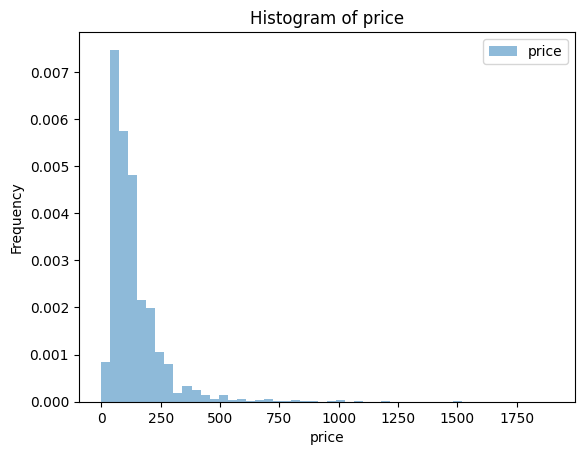

In [11]:
train_df[train_df["price"] < 2000]["price"].plot.hist(bins=50, alpha=0.5, legend=True, density=True, title ="Histogram of price")
plt.xlabel("price")
plt.show()

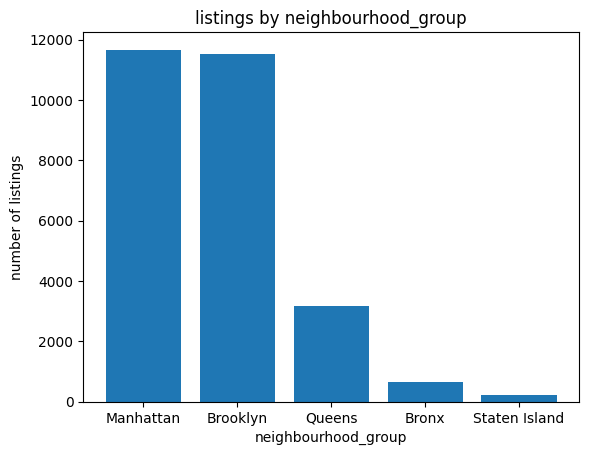

In [12]:
plt.bar(neighbourhood_group_count.index, neighbourhood_group_count.values)
plt.title('listings by neighbourhood_group')
plt.xlabel('neighbourhood_group')
plt.ylabel('number of listings')
plt.show()

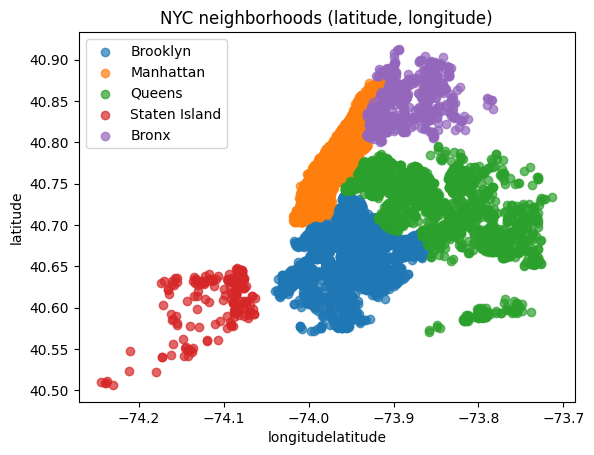

In [15]:
for cls in train_df["neighbourhood_group"].unique():
    idx = train_df["neighbourhood_group"] == cls
    plt.scatter(train_df["longitude"][idx], train_df["latitude"][idx], label=cls, alpha=0.7)
plt.xlabel("longitude""latitude")
plt.ylabel("latitude")
plt.legend()
plt.title("NYC neighborhoods (latitude, longitude)")
plt.show()

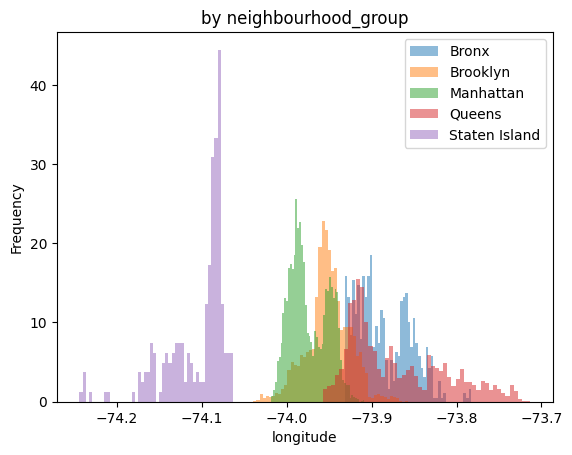

In [11]:
train_df.groupby("neighbourhood_group")["longitude"].plot.hist(bins=50, alpha=0.5, legend=True, density=True, title ="by neighbourhood_group")
plt.xlabel("longitude")
plt.show()

neighbourhood_group
Bronx             79.553653
Brooklyn         121.448714
Manhattan        180.052489
Queens            95.762571
Staten Island     89.964968
Name: price, dtype: float64


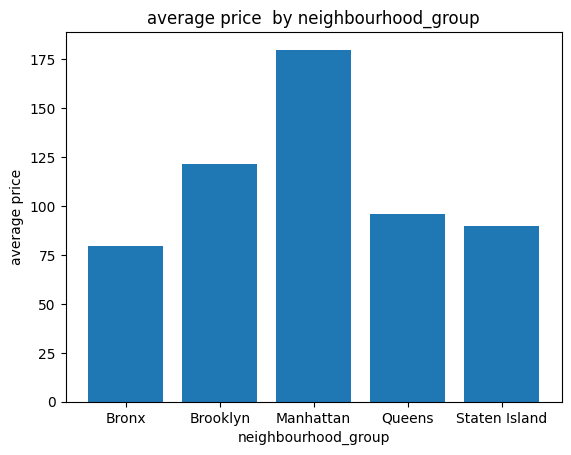

In [12]:
avg_price_by_neighbourhood_group = df.groupby('neighbourhood_group')['price'].mean()
print(avg_price_by_neighbourhood_group)

plt.bar(avg_price_by_neighbourhood_group.index, avg_price_by_neighbourhood_group.values)
plt.title('average price  by neighbourhood_group')
plt.xlabel('neighbourhood_group')
plt.ylabel('average price')
plt.show()

neighbourhood_group
Bronx            170.940639
Brooklyn         105.879309
Manhattan        109.322932
Queens           150.508308
Staten Island    205.640127
Name: availability_365, dtype: float64


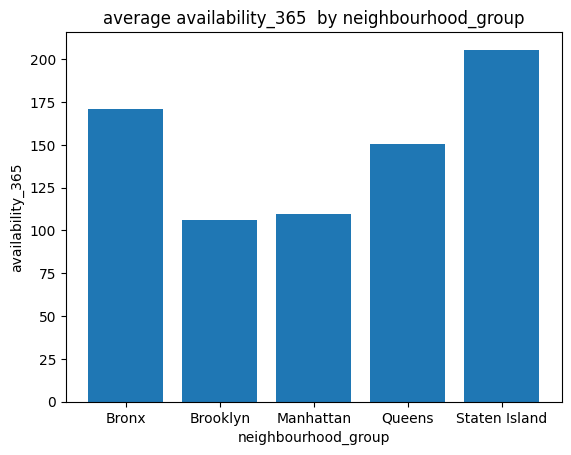

In [13]:
avg_availability_365_by_neighbourhood_group = df.groupby('neighbourhood_group')['availability_365'].mean()
print(avg_availability_365_by_neighbourhood_group)

plt.bar(avg_availability_365_by_neighbourhood_group.index, avg_availability_365_by_neighbourhood_group.values)
plt.title('average availability_365  by neighbourhood_group')
plt.xlabel('neighbourhood_group')
plt.ylabel('availability_365')
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

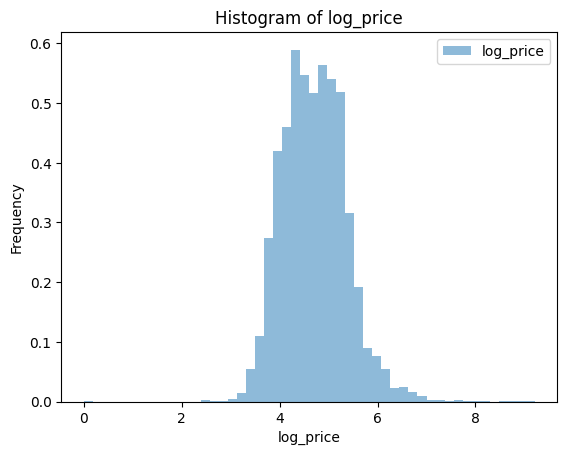

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,log_price
14989,11937647,Entire Williamsburg apt.,12446288,Micki & Kristian,Brooklyn,Williamsburg,40.71541,-73.93748,Entire home/apt,110,3,4,2018-05-30,0.10,1,0,4.709530
40517,31409612,Tremendous Views - Greenpoint,56061729,Dennis,Brooklyn,Greenpoint,40.73421,-73.95318,Entire home/apt,125,2,8,2019-06-10,1.37,1,188,4.836282
32631,25635216,Clean and Nice Central Park Apt in Lincoln Center,193127179,Sagawa,Manhattan,Upper West Side,40.77640,-73.98236,Private room,85,4,18,2019-05-03,1.38,1,133,4.454347
39464,30747515,Bedstuy-stay,20043437,Marianne,Brooklyn,Bedford-Stuyvesant,40.68581,-73.95189,Private room,35,10,3,2019-05-31,0.48,1,5,3.583519
26165,20864878,High Line Sun Drenched Home,13462349,Elvis,Manhattan,Chelsea,40.74690,-73.99494,Entire home/apt,200,2,40,2019-06-19,1.81,1,288,5.303305


In [14]:
# adding log price to compensate for log like skew of prices as shown earlier

train_df = train_df.assign(log_price=np.log1p(train_df["price"]))
test_df = test_df.assign(log_price=np.log1p(test_df["price"]))

train_df["log_price"].plot.hist(bins=50, alpha=0.5, legend=True, density=True, title ="Histogram of log_price")
plt.xlabel("log_price")
plt.show()

train_df.head()

In [15]:
train_df = train_df.assign(minimum_stay_price = train_df["price"]*train_df["minimum_nights"])
test_df = test_df.assign(minimum_stay_price = test_df["price"]*test_df["minimum_nights"])

X_train, y_train = (
    train_df.drop(columns=["reviews_per_month"]),
    train_df["reviews_per_month"],
)
X_test, y_test = (
    test_df.drop(columns=["reviews_per_month"]),
    test_df["reviews_per_month"],
)


In [16]:
numeric_feats = ["price",
                 "minimum_nights",
                 "number_of_reviews",                 
                 "calculated_host_listings_count",
                 "availability_365",
                 "minimum_stay_price",
                 "log_price"]  # apply scaling

categorical_feats = ["host_id", 
                     "host_name", 
                     "neighbourhood_group", 
                     "neighbourhood",
                     "room_type",
                    ]  # apply one-hot encoding

ordinal_feats = []  # apply ordinal encoding

passthrough_feats = []  # do not apply any transformation

discretization_feats = ["latitude","longitude"] # for bins discretizer

text_feats = [] # apply CountVectorizer

drop_feats = ["id","last_review", "name"]  # do not include these features


In [17]:
ct = make_column_transformer(
    (
        make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
        numeric_feats
    ),
    (KBinsDiscretizer(n_bins=10, encode="onehot", strategy="quantile", quantile_method="linear"), discretization_feats),    
    (OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ("drop", drop_feats)
)

ct.fit(X_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('kbinsdiscretizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [18]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [19]:
dummy_regressor = make_pipeline(ct, DummyRegressor())
scores = cross_validate(dummy_regressor, X_train, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.096257,0.036329,-2.055798e-04,0.0
1,0.102558,0.043503,-6.196033e-05,0.0
2,0.084863,0.032631,-9.107902e-08,0.0
3,0.087089,0.035345,-2.852642e-06,0.0
4,0.099696,0.032001,-2.111910e-05,0.0


In [20]:
...

Ellipsis

In [21]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [22]:
ridge_regressor = make_pipeline(ct, Ridge())
ridge_scores = cross_validate(ridge_regressor, X_train, y_train, return_train_score=True)
pd.DataFrame(ridge_scores)



,fit_time,score_time,test_score,train_score
0,3.268101,0.050527,0.421774,0.875486
1,3.713525,0.058327,0.434469,0.875042
2,3.225901,0.053233,0.456549,0.875292
3,2.774166,0.060823,0.446769,0.873094
4,1.927010,0.052536,0.479899,0.872822


In [23]:
scores_dict = {
    "alpha": 10.0 ** np.arange(-3, 6, 1),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}

for alpha in scores_dict["alpha"]:
    pipe_ridge = make_pipeline(ct, Ridge(alpha=alpha))
    scores = cross_validate(pipe_ridge, X_train, y_train, return_train_score=True)
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)


In [24]:
best_alpha_idx = results_df["mean_cv_scores"].argmax()
best_alpha = results_df.loc[best_alpha_idx,"alpha"]
print("best value of alpha: ", best_alpha)
results_df


best value of alpha:  1.0


,alpha,mean_train_scores,mean_cv_scores
0,0.001,0.964125,0.370000
1,0.010,0.963983,0.403271
2,0.100,0.960785,0.429883
3,1.000,0.874347,0.447892
4,10.000,0.564715,0.412444
5,100.000,0.399555,0.370474
6,1000.000,0.356863,0.349951
7,10000.000,0.310242,0.307664
8,100000.000,0.117607,0.117236


In [25]:
pipe_ridge = make_pipeline(ct, Ridge(alpha=best_alpha))
scores = cross_validate(pipe_ridge, X_train, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.602703,0.093349,0.421774,0.875486
1,0.870491,0.054745,0.434469,0.875042
2,1.574141,0.052661,0.456549,0.875292
3,0.600598,0.055759,0.446769,0.873094
4,0.774471,0.053137,0.479899,0.872822


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

The best test score is demonstrated by the random_forest_regressor with the value of validation score in the range from 0.50-0.53. It is also the model that very long time to train (10-11)
SVR is slightly worse with cv scores in the range 0.44 -0.48 and enormous fit and score times (154 and 8.5)
Linear model has lower score of 0.45.
KNeighbours regressor demonstrated the worst result with validation score in the range 0.25-0.31. It was fairly quick to fit and slow to score.

In [26]:

random_forest_regressor = make_pipeline(ct, RandomForestRegressor(max_depth=7, n_estimators=50))
random_forest_scores = cross_validate(random_forest_regressor, X_train, y_train, return_train_score=True)
pd.DataFrame(random_forest_scores)



,fit_time,score_time,test_score,train_score
0,9.305723,0.055017,0.492278,0.568030
1,6.726054,0.051137,0.507444,0.567840
2,9.064976,0.049995,0.524672,0.560463
3,8.796342,0.056626,0.514916,0.562672
4,9.227055,0.049147,0.538015,0.557207


In [27]:
from sklearn.neighbors import KNeighborsRegressor

kN_regressor = make_pipeline(ct, KNeighborsRegressor(n_neighbors=3))
kN_scores = cross_validate(kN_regressor, X_train, y_train, return_train_score=True)
pd.DataFrame(kN_scores)

,fit_time,score_time,test_score,train_score
0,0.094513,0.552266,0.323809,0.684859
1,0.088391,2.407051,0.320616,0.691323
2,0.082246,2.410341,0.356416,0.680907
3,0.092487,2.634377,0.355361,0.684902
4,0.081794,2.529818,0.379138,0.676603


In [28]:
svr_regressor = make_pipeline(ct, SVR())
svr_scores = cross_validate(svr_regressor, X_train, y_train, return_train_score=True)
pd.DataFrame(svr_scores)

,fit_time,score_time,test_score,train_score
0,65.210638,4.341524,0.452117,0.579581
1,65.167657,2.494083,0.442614,0.579132
2,65.557823,3.826456,0.463473,0.571000
3,70.107789,2.542808,0.478019,0.577443
4,66.035246,2.813739,0.483705,0.565027


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [ ]:
from sklearn.feature_selection import RFECV

X_train_scaled = ct.fit_transform(X_train)
rfe_cv = RFECV(Ridge(alpha=best_alpha), cv=5)
rfe_cv.fit(X_train_scaled, y_train)


In [ ]:
print(rfe_cv.support_)
print(rfe_cv.n_features_)
print("rfe selected features: ", X_train_scaled.feature_names[rfe_cv.support_])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [36]:
from sklearn.model_selection import RandomizedSearchCV

random_forest_regressor = make_pipeline(ct, RandomForestRegressor(max_depth=2, n_estimators=10))
#print(random_forest_regressor.get_params())

param_grid = {
    "randomforestregressor__n_estimators": [10, 20, 50],
    "randomforestregressor__max_depth": [2, 5, 10]    
}

print("Grid size: %d" % (np.prod(list(map(len, param_grid.values())))))
param_grid




Grid size: 9


{'randomforestregressor__n_estimators': [10, 20, 50],
 'randomforestregressor__max_depth': [2, 5, 10]}

In [37]:

random_search = RandomizedSearchCV(random_forest_regressor,                                    
                  param_distributions = param_grid, 
                  n_iter=20, 
                  n_jobs=-1, 
                  return_train_score=True)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...imators=10))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestregressor__max_depth': [2, 5, ...], 'randomforestregressor__n_estimators': [10, 20, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [40]:

pd.DataFrame(random_search.cv_results_).set_index("rank_test_score").sort_index().T

rank_test_score,1,2,3,4,5,6,7,8,9
mean_fit_time,25.868398,12.287154,6.277837,11.410034,4.81497,2.698774,1.456454,3.403659,0.920547
std_fit_time,2.342997,0.574769,1.349705,0.814792,0.401636,0.3646,0.078625,0.308542,0.08856
mean_score_time,0.067206,0.095713,0.083728,0.104544,0.08949,0.089324,0.095118,0.115783,0.092632
std_score_time,0.013039,0.012009,0.018819,0.015818,0.004307,0.014784,0.016324,0.021106,0.008456
param_randomforestregressor__n_estimators,50,20,10,50,20,10,20,50,10
param_randomforestregressor__max_depth,10,10,10,5,5,5,2,2,2
params,"{'randomforestregressor__n_estimators': 50, 'r...","{'randomforestregressor__n_estimators': 20, 'r...","{'randomforestregressor__n_estimators': 10, 'r...","{'randomforestregressor__n_estimators': 50, 'r...","{'randomforestregressor__n_estimators': 20, 'r...","{'randomforestregressor__n_estimators': 10, 'r...","{'randomforestregressor__n_estimators': 20, 'r...","{'randomforestregressor__n_estimators': 50, 'r...","{'randomforestregressor__n_estimators': 10, 'r..."
split0_test_score,0.50642,0.502641,0.50323,0.473708,0.472013,0.466833,0.35914,0.356229,0.354173
split1_test_score,0.522409,0.523813,0.51682,0.488671,0.487279,0.485857,0.367994,0.364445,0.359164
split2_test_score,0.542839,0.541306,0.540238,0.501685,0.501769,0.501001,0.362736,0.359924,0.360584


In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [47]:
random_forest_regressor = make_pipeline(ct, RandomForestRegressor(max_depth=5, n_estimators=20))
random_forest_regressor.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('kbinsdiscretizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [54]:
print(random_forest_regressor.named_steps)
#print(random_forest_regressor.named_steps["randomforestregressor"].feature_importances_)
data = {"Importance": random_forest_regressor.named_steps["randomforestregressor"].feature_importances_,}
feature_names = random_forest_regressor.named_steps["columntransformer"].get_feature_names_out()

rf_imp_df = pd.DataFrame(
    data=data,
    index=feature_names,
).sort_values(by="Importance", ascending=False)
rf_imp_df

{'columntransformer': ColumnTransformer(transformers=[('pipeline',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews',
                                  'calculated_host_listings_count',
                                  'availability_365', 'minimum_stay_price',
                                  'log_price']),
                                ('kbinsdiscretizer',
                                 KBinsDiscretizer(n_bins=10,
                                                  quantile_method='linear'),
                                 ['latitude', 'longitude']),
                                ('onehotencoder',
                               

,Importance
pipeline__number_of_reviews,0.647095
pipeline__minimum_nights,0.188964
pipeline__availability_365,0.106182
onehotencoder__neighbourhood_Springfield Gardens,0.010952
kbinsdiscretizer__longitude_9.0,0.009449
...,...
onehotencoder__host_id_21315876,0.000000
onehotencoder__host_id_21307389,0.000000
onehotencoder__host_id_21299191,0.000000
onehotencoder__host_id_21296382,0.000000


/tmp/ipykernel_2111/3787768667.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


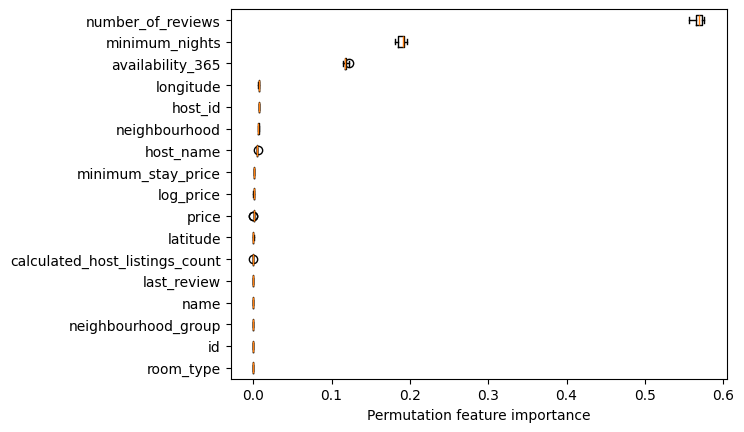

In [57]:
from sklearn.inspection import permutation_importance
def get_permutation_importance(model):    
    result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=123)
    sorted_idx = result.importances_mean.argsort()
    plt.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        labels=X_train.columns[sorted_idx],
    )
    plt.xlabel('Permutation feature importance')
    plt.show()

get_permutation_importance(random_forest_regressor)

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [59]:
random_forest_regressor = make_pipeline(ct, RandomForestRegressor(max_depth=7, n_estimators=50))
random_forest_regressor.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('kbinsdiscretizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [60]:
test_score = random_forest_regressor.score(X_test, y_test)
print(test_score)

0.4686892731147251


In [61]:
test_score

0.4686892731147251

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Instructions section at the top.

Here is a quick checklist before submitting:

- [ ] Restart the kernel and run all cells.
- [ ] `hw5.ipynb` runs without errors and contains all outputs.
- [ ] Save `hw5.ipynb` in JupyterLab.
- [ ] Return to the PrairieLearn question page and click **Save only** to check the rendered notebook preview.
- [ ] When the preview looks correct, click **Save & Grade**.
- [ ] If you are working in a group, confirm your PrairieLearn group membership is correct.
- [ ] Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for details on the grading process.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)